In [1]:
# Cell 1: Import all necessary libraries
import requests
import pandas as pd
import numpy as np
import math
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import json
from collections import defaultdict
print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
API_KEY = "d881de71e6cf19a923c0139398067320"
LAT = 51.5074  # London coordinates
LON = -0.1278   # Change these to your desired location

# Crop coefficients database
CROP_COEFFICIENTS = {
    "grass": 1.00,
    "wheat": 1.05,
    "barley": 1.00,
    "maize": 1.10,
    "tomatoes": 1.15,
    "potatoes": 1.10,
    "lettuce": 1.00,
    "cabbage": 1.05,
    "cotton": 1.15,
    "soybeans": 1.05,
    "vineyard": 0.70,
    "orchard": 0.90,
    "alfalfa": 0.95
}

SELECTED_CROP = "tomatoes"  # Default crop selection

In [3]:
def wind_speed_10m_to_2m(u10):
    """Convert wind speed from 10m height to 2m height"""
    return u10 * (4.87 / math.log((67.8 * 10) - 5.42))

def calculate_solar_declination(day_of_year):
    """Calculate solar declination in radians"""
    return 0.409 * math.sin(2 * math.pi / 365 * day_of_year - 1.39)

def calculate_daylight_hours(lat, solar_declination):
    """Calculate daylight hours"""
    lat_rad = math.radians(lat)
    sunset_hour_angle = math.acos(-math.tan(lat_rad) * math.tan(solar_declination))
    return 24 / math.pi * sunset_hour_angle

def calculate_extraterrestrial_radiation(lat, day_of_year):
    """Calculate extraterrestrial radiation (Ra) in MJ/m²/day"""
    solar_declination = calculate_solar_declination(day_of_year)
    daylight_hours = calculate_daylight_hours(lat, solar_declination)
    
    G_sc = 0.0820  # Solar constant (MJ/m²/min)
    dr = 1 + 0.033 * math.cos(2 * math.pi / 365 * day_of_year)  # Inverse relative distance Earth-Sun
    
    lat_rad = math.radians(lat)
    term1 = 24 * 60 / math.pi * G_sc * dr
    term2 = math.acos(-math.tan(lat_rad) * math.tan(solar_declination))
    term3 = math.sin(lat_rad) * math.sin(solar_declination) * term2
    term4 = math.cos(lat_rad) * math.cos(solar_declination) * math.sin(term2)
    
    Ra = term1 * (term3 + term4)
    return Ra


In [4]:
def calculate_et0(weather_data, lat, lon):
    """
    Calculate daily reference evapotranspiration (ET0) using FAO Penman-Monteith equation
    """
    try:
        # Extract weather parameters
        T_min = weather_data['temp']['min']
        T_max = weather_data['temp']['max']
        T_mean = (T_min + T_max) / 2
        RH_mean = weather_data.get('humidity', 60)
        u10 = weather_data.get('wind_speed', 2.0)
        cloudiness = weather_data.get('clouds', 50)
        
        # Get date information
        dt = weather_data.get('dt', datetime.now().timestamp())
        date = datetime.fromtimestamp(dt)
        day_of_year = date.timetuple().tm_yday
        
        # Convert wind speed from 10m to 2m height
        u2 = wind_speed_10m_to_2m(u10)
        
        # Calculate saturation and actual vapor pressure
        es = 0.6108 * math.exp(17.27 * T_mean / (T_mean + 237.3))  # kPa
        ea = es * (RH_mean / 100)  # kPa
        
        # Calculate slope of vapor pressure curve
        Delta = (4098 * es) / ((T_mean + 237.3) ** 2)  # kPa/°C
        
        # Psychrometric constant (assuming standard atmospheric pressure)
        gamma = 0.665 * 0.001  # kPa/°C
        
        # Calculate extraterrestrial radiation
        Ra = calculate_extraterrestrial_radiation(lat, day_of_year)
        
        # Estimate solar radiation from cloudiness (simplified approach)
        Rs = Ra * (0.75 + 0.00002 * 0) * (1 - (cloudiness / 100))  # Simple cloud adjustment
        
        # Calculate net radiation (simplified)
        Rns = 0.77 * Rs  # Net shortwave radiation
        Rnl = 4.903e-9 * ((T_max + 273.16) ** 4 + (T_min + 273.16) ** 4) / 2 * (0.34 - 0.14 * math.sqrt(ea)) * (1.35 * (Rs / (Ra + 0.0001)) - 0.35)
        Rn = Rns - Rnl  # Net radiation
        
        # Soil heat flux (negligible for daily calculations)
        G = 0
        
        # Apply FAO Penman-Monteith equation
        numerator = (0.408 * Delta * (Rn - G)) + (gamma * (900 / (T_mean + 273)) * u2 * (es - ea))
        denominator = Delta + (gamma * (1 + 0.34 * u2))
        et0 = numerator / denominator
        
        return max(0, round(et0, 2))
        
    except Exception as e:
        print(f"Error calculating ET0: {e}")
        # Fallback calculation based on temperature
        T_mean = (weather_data['temp']['min'] + weather_data['temp']['max']) / 2
        return max(0, round(T_mean * 0.2, 2))


In [5]:
# Cell 5: Process 3-hour forecast data into daily aggregates
def process_forecast_to_daily(forecast_data):
    """Convert 3-hour forecast data into daily summaries"""
    daily_data = defaultdict(lambda: {
        'temp_min': float('inf'),
        'temp_max': float('-inf'),
        'humidity_sum': 0,
        'wind_speed_sum': 0,
        'cloudiness_sum': 0,
        'count': 0,
        'dt': None
    })
    
    for entry in forecast_data['list']:
        date_str = datetime.fromtimestamp(entry['dt']).strftime('%Y-%m-%d')
        day_data = daily_data[date_str]
        
        # Get temperature values (handle different API response structures)
        temp_min = entry['main'].get('temp_min', entry['main']['temp'])
        temp_max = entry['main'].get('temp_max', entry['main']['temp'])
        
        # Update min/max temperatures
        day_data['temp_min'] = min(day_data['temp_min'], temp_min)
        day_data['temp_max'] = max(day_data['temp_max'], temp_max)
        
        # Sum other parameters for averaging
        day_data['humidity_sum'] += entry['main']['humidity']
        day_data['wind_speed_sum'] += entry['wind']['speed']
        day_data['cloudiness_sum'] += entry['clouds']['all']
        day_data['count'] += 1
        day_data['dt'] = entry['dt']  # Use the timestamp of the last entry for the day
    
    # Convert to the format expected by calculate_et0
    processed_daily = []
    for date_str, data in daily_data.items():
        if data['count'] > 0:
            processed_daily.append({
                'dt': data['dt'],
                'temp': {
                    'min': data['temp_min'],
                    'max': data['temp_max']
                },
                'humidity': data['humidity_sum'] / data['count'],
                'wind_speed': data['wind_speed_sum'] / data['count'],
                'clouds': data['cloudiness_sum'] / data['count']
            })
    
    return processed_daily


In [ ]:
# Cell 6: Fetch weather data from OpenWeatherMap API
def fetch_weather_data(api_key, lat, lon):
    """Fetch current and forecast weather data from OpenWeatherMap"""
    try:
        # Use the 2.5 forecast API
        url = f"https://api.openweathermap.org/data/2.5/forecast?lat={lat}&lon={lon}&appid={api_key}&units=metric"
        response = requests.get(url, timeout=15)
        response.raise_for_status()
        data = response.json()
        
        # Process the 3-hour forecast data into daily format
        daily_forecast = process_forecast_to_daily(data)
        return {'daily': daily_forecast}
        
    except requests.exceptions.RequestException as e:
        print(f"Error fetching weather data: {e}")
        # Return fallback data if API fails
        return create_fallback_data()
    except json.JSONDecodeError as e:
        print(f"Error parsing weather data: {e}")
        return create_fallback_data()

def create_fallback_data():
    """Create fallback data for demonstration purposes"""
    current_time = datetime.now()
    fallback_data = []
    
    for i in range(5):
        day_time = current_time + timedelta(days=i)
        fallback_data.append({
            'dt': day_time.timestamp(),
            'temp': {
                'min': 10 + i * 2,
                'max': 20 + i * 2
            },
            'humidity': 60 + i * 5,
            'wind_speed': 2.0 + i * 0.5,
            'clouds': 30 + i * 10
        })
    
    return {'daily': fallback_data}


🌱 AgriSmart ET Calculator - Starting Analysis...

Location: Latitude 51.5074, Longitude -0.1278
Selected Crop: tomatoes
--------------------------------------------------


✅ Weather data processed successfully!

DAILY EVAPOTRANSPIRATION (ET0) FORECAST
2025-09-16 (Tue): 1.01 mm/day | Temp: 17.5°C to 18.2°C | Humidity: 53.0%
2025-09-17 (Wed): 0.93 mm/day | Temp: 13.5°C to 17.9°C | Humidity: 80.5%
2025-09-18 (Thu): 2.65 mm/day | Temp: 16.6°C to 23.5°C | Humidity: 75.5%
2025-09-19 (Fri): 1.11 mm/day | Temp: 15.6°C to 25.6°C | Humidity: 64.2%
2025-09-20 (Sat): 1.13 mm/day | Temp: 15.6°C to 23.3°C | Humidity: 62.5%
2025-09-21 (Sun): 1.42 mm/day | Temp: 14.7°C to 19.0°C | Humidity: 83.3%

💧 Crop Water Needs for tomatoes (Kc = 1.15):
2025-09-16 (Tue): 1.2 mm
2025-09-17 (Wed): 1.1 mm
2025-09-18 (Thu): 3.0 mm
2025-09-19 (Fri): 1.3 mm
2025-09-20 (Sat): 1.3 mm
2025-09-21 (Sun): 1.6 mm


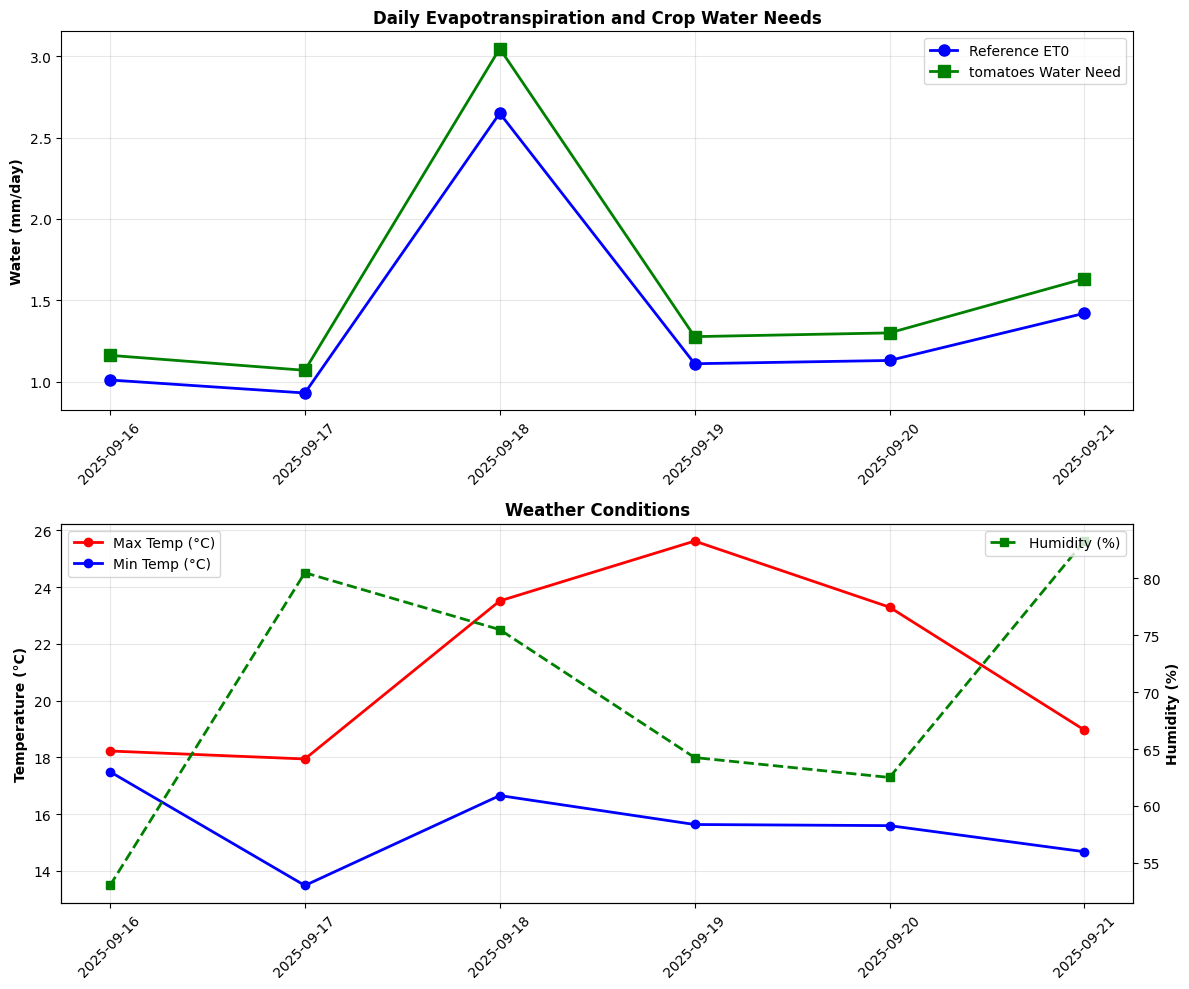


IRRIGATION RECOMMENDATIONS

Today (2025-09-16 (Tue)):
  • Reference ET0: 1.01 mm
  • tomatoes water need: 1.2 mm
  ✅ No frost risk detected
  💧 Recommendation: Apply 1.2 mm irrigation
  ☁️  Cloudy conditions today - reduced evaporation expected

📅 Weekly Water Planning:
  • Total water needed this week: 9.5 mm
  • Average daily need: 1.6 mm/day


In [7]:
# Cell 7: Main execution and analysis
print("🌱 AgriSmart ET Calculator - Starting Analysis...\n")
print(f"Location: Latitude {LAT}, Longitude {LON}")
print(f"Selected Crop: {SELECTED_CROP}")
print("-" * 50)

# Fetch weather data
weather_data = fetch_weather_data(API_KEY, LAT, LON)

if weather_data and 'daily' in weather_data:
    print("✅ Weather data processed successfully!")
    
    # Calculate ET0 for available days
    et0_results = []
    for i, daily_data in enumerate(weather_data['daily']):
        et0 = calculate_et0(daily_data, LAT, LON)
        date = datetime.fromtimestamp(daily_data['dt']).strftime('%Y-%m-%d (%a)')
        et0_results.append({
            'date': date,
            'et0': et0,
            'min_temp': daily_data['temp']['min'],
            'max_temp': daily_data['temp']['max'],
            'humidity': daily_data['humidity'],
            'wind_speed': daily_data['wind_speed'],
            'cloudiness': daily_data['clouds']
        })
    
    # Create DataFrame for analysis
    df = pd.DataFrame(et0_results)
    
    # Display results
    print("\n" + "="*60)
    print("DAILY EVAPOTRANSPIRATION (ET0) FORECAST")
    print("="*60)
    
    for _, row in df.iterrows():
        print(f"{row['date']}: {row['et0']} mm/day | Temp: {row['min_temp']:.1f}°C to {row['max_temp']:.1f}°C | Humidity: {row['humidity']:.1f}%")
    
    # Calculate crop water need
    kc = CROP_COEFFICIENTS[SELECTED_CROP]
    df['crop_water_need'] = df['et0'] * kc
    
    print(f"\n💧 Crop Water Needs for {SELECTED_CROP} (Kc = {kc}):")
    for _, row in df.iterrows():
        print(f"{row['date']}: {row['crop_water_need']:.1f} mm")
        
    # Cell 8: Visualization
    if not df.empty:
        # Create visualization
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
        
        # ET0 and Water Need Chart
        dates = [datetime.strptime(row['date'][:10], '%Y-%m-%d') for _, row in df.iterrows()]
        ax1.plot(dates, df['et0'], 'o-', label='Reference ET0', linewidth=2, markersize=8, color='blue')
        ax1.plot(dates, df['crop_water_need'], 's-', label=f'{SELECTED_CROP} Water Need', linewidth=2, markersize=8, color='green')
        ax1.set_ylabel('Water (mm/day)', fontweight='bold')
        ax1.set_title('Daily Evapotranspiration and Crop Water Needs', fontweight='bold')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
        
        # Weather Parameters Chart
        ax2.plot(dates, df['max_temp'], 'r-o', label='Max Temp (°C)', markersize=6, linewidth=2)
        ax2.plot(dates, df['min_temp'], 'b-o', label='Min Temp (°C)', markersize=6, linewidth=2)
        ax2.set_ylabel('Temperature (°C)', fontweight='bold')
        ax2.legend(loc='upper left')
        
        ax2_twin = ax2.twinx()
        ax2_twin.plot(dates, df['humidity'], 'g--s', label='Humidity (%)', markersize=6, linewidth=2)
        ax2_twin.set_ylabel('Humidity (%)', fontweight='bold')
        ax2_twin.legend(loc='upper right')
        
        ax2.set_title('Weather Conditions', fontweight='bold')
        ax2.grid(True, alpha=0.3)
        plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
        
        plt.tight_layout()
        plt.show()
        
    # Cell 9: Irrigation Recommendations
    print("\n" + "="*60)
    print("IRRIGATION RECOMMENDATIONS")
    print("="*60)
    
    today = df.iloc[0]
    
    print(f"\nToday ({today['date']}):")
    print(f"  • Reference ET0: {today['et0']} mm")
    print(f"  • {SELECTED_CROP} water need: {today['crop_water_need']:.1f} mm")
    
    # Frost check
    if today['min_temp'] <= 1.0:
        print("  ❄️  FROST WARNING: Minimum temperature ≤ 1°C tonight!")
        print("  💡 Recommendation: Delay irrigation and protect sensitive crops")
    elif today['min_temp'] <= 3.0:
        print("  ⚠️  Frost Risk: Minimum temperature ≤ 3°C tonight")
        print("  💡 Recommendation: Monitor conditions and consider light irrigation")
    else:
        print("  ✅ No frost risk detected")
        print(f"  💧 Recommendation: Apply {today['crop_water_need']:.1f} mm irrigation")
    
    # Additional recommendations based on weather
    if today['cloudiness'] > 70:
        print("  ☁️  Cloudy conditions today - reduced evaporation expected")
    if today['wind_speed'] > 5.0:
        print("  💨 Windy conditions - increased evaporation expected")
    
    # Weekly planning
    print(f"\n📅 Weekly Water Planning:")
    weekly_need = df['crop_water_need'].sum()
    print(f"  • Total water needed this week: {weekly_need:.1f} mm")
    print(f"  • Average daily need: {df['crop_water_need'].mean():.1f} mm/day")
        
else:
    print("❌ Failed to process weather data.")